# **<span style="color: #000000;background-color: #fff5b1">연관분석+경영기초 사전과제</span>**

### **필수내용**
- **연관 분석** 
    - 연관 분석의 정의
    - 지지도, 신뢰도, 향상도
    - 연관 분석의 알고리즘
        - Apriori 알고리즘
        - FP Growth 알고리즘
- **경영 기초**
    - 문제 정의와 문제 구조화
    - 지표
        - 북극성 지표, L1/L2 Metrics
        - AARRR
    - 지표 분석 방법
        - 코호트 분석
        - 퍼널 분석

---

## <span style="color: #ff9165">**<연관 분석>**</span>

### <span style="color: #000000;background-color: #ffdba4">**1. 연관 분석이란?**</span>

#### <span style="color: #000000;background-color: #ffc2e5">   **1-(1) 연관 분석의 정의**</span>
<U>**상품이나 서비스를 구매하는 등 일련의 거래나 사건 안에 존재하는 항목 간의 일정한 <span style="color: #ff0000">연관 규칙</span>을 발견하는 분석**</U>

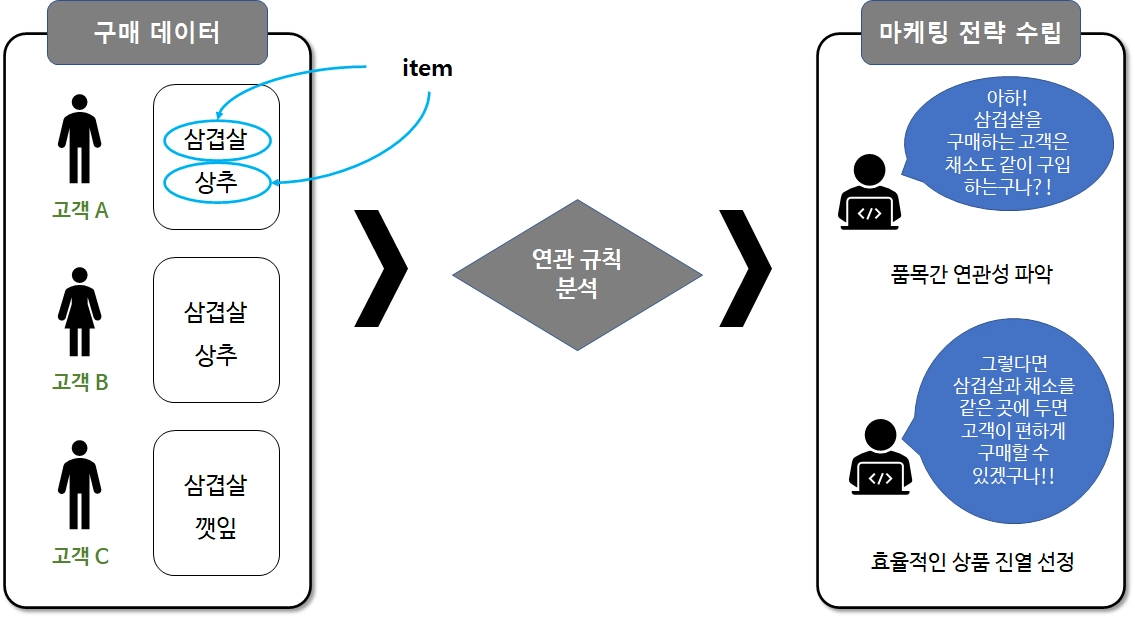
- *장바구니 분석* : 연관 분석의 한 분야로, 유통업에서 사용하는 용어
    - 연관 분석은 타 분야에도 폭넓게 사용 가능하다.
- **비지도 학습**
- 알고리즘 : Apriori, FP-Growth

#### <span style="color: #000000;background-color: #ffc2e5">   **1-(2) 연관규칙 분석**</span>
- **연관규칙의 형태**
    - if-then의 형식 : <U>'A를 구매했을 때, B도 구매할 것이다'</U> [A->B]
    - 예시 : "라면을 구매하는 사람들은 달걀도 함께 산다."
        - 조건절 : '만일 ~라면'에 해당하는 부분 (라면 구매)
        - 결과절 : 그 뒷부분에 해당하는 내용 (달걀 구매)
        - 아이템 집합 : 조건절 또는 결과절을 구성하는 아이템들의 집합, 상호배반 (라면,달걀)

- **연관규칙 주의** 
    - 상관관계만 파악할 뿐, <span style="color : #ff0000 ">인과관계는 알 수 없다!</span>
    - 예시 : "A를 산 사람 중 80%는 B도 샀다." -> 단지 함께 자주 나타난다는 패턴일 뿐, 원인-결과 관계로 볼 수는 없다
    - 이유
        1. 실험이 아닌 관찰 데이터
            - A를 산 원인이 통제되지 않았으며, 숨겨진 공통원인이 있을 수 있다.
        2. 방향성은 단지 수학적 비율
            - A->B는 "A가 원인이다" X / "A 샀을 때 B 산 비율이 높다" O
        3. 상관관계 $\neq$ 인과관계


### <span style="color: #000000;background-color: #ffdba4">**2. 주요 개념**</span>

#### <span style="color: #000000;background-color: #ffc2e5">   **2-(1) (적절한) 연관규칙의 조건**</span>
1. 일정 이상의 지지도
    - 두 품목(A와 B)이 함께 구매한 경우의 수가 일정 수준 이상이어야 한다.
2. 일정 이상의 신뢰도
    - 품목 A를 포함하는 거래 중 품목 B를 구입하는 경우의 수가 일정 수준 이상이어야 한다.

##### <span style="color: #27baff">   **[지지도(Support)]** <span>
<U>전체 거래항목 중 품목 A와 B가 동시에 포함되는 거래의 비율</U>

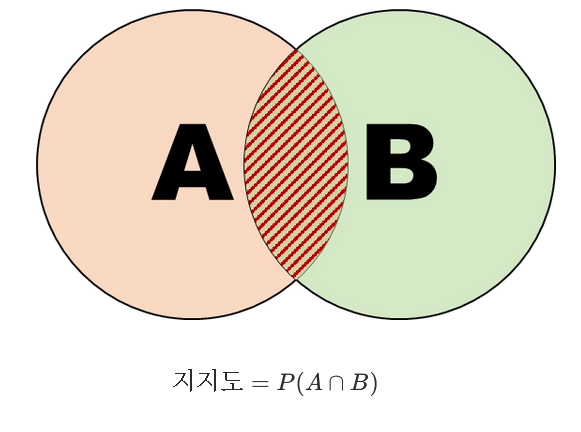
- '이 규칙이 현실에서 의미 있는가?'를 판단하는 가장 1차적인 기준

##### <span style="color: #27baff">   **[신뢰도(Confidence)]** <span>
<U>품목 A를 포함하는 거래 중 A와 B가 동시에 포함하는 거래의 비율</U>



#### <span style="color: #000000;background-color: #ffc2e5">   **2-(2) 연관 분석의 평가 측도**</span>
##### <span style="color: #27baff">   **[향상도]** <span>
<U>A가 주어지지 않았을 때의 B의 확률 대비, A가 주어졌을 때의 B의 확률의 증가 비율</U>
- 핵심 아이디어 : "A와 B가 우연히 함께 등장할 확률과 실제 함께 등장할 확률 비교"
- $향상도 = \frac{P(A \cap B)}{P(A)P(B)} = \frac{신뢰도}{P(B)}$
1. 독립일 때 기댓값
    - 사건 A와 B가 독립 
        - $P(A∩B)=P(A)⋅P(B)$ : A를 샀다는 사실이 B를 살 확률에 영향을 주지 않는다!
        - 향상도는 항상 1
    - 사건 A와 B가 독립이 아니라면
        - $P(A∩B)=P(A)⋅P(B∣A)=P(B)⋅P(A∣B)$ : A를 샀다는 사실이 B를 살 확률에 영향을 주거나, B를 샀다는 사실이 A를 살 확률에 영향을 준다!
        - 향상도 != 1
2. 실제 동시 발생 확률
    - 우리가 실제로 관측한 $P(A∩B)$가 A와 B가 함께 등장할 확률의 기댓값 $P(A)\cdot P(B)$보다
        - 크면 : 양의 연관성 
        - 작으면 : 음의 연관성
3. 비율로 비교
    - 향상도>1 : 두 품목이 양의 상관관계
    - 향상도=1 : 독립
    - 향상도<1 : 두 품목이 음의 상관관계

### <span style="color: #000000;background-color: #ffdba4">**3. 연관 분석 알고리즘**</span>

#### <span style="color: #000000;background-color: #ffc2e5">   **3-(1) Aporiori 알고리즘**</span>
> 선험적 경험 이용
##### <span style="color: #27baff">   **[배경 : 무차별 탐색의 비효율]** <span>
- 연관 규칙을 찾기 위해 가능한 모든 조합을 시도하는 것은 매우 비효율적
    - 가능한 모든 조합 : A(선행조건) -> B(결과조건)로 표현되도록 하는 모든 경우의 수
    -> A와 B가 여러 품목으로 구성된 복합조건일 수도 있다.
- 상품의 개수가 많아질수록 조합의 수가 매우 급증

##### <span style="color: #27baff">   **[Apriori 알고리즘 소개]** <span>
- 개념
    - 상위 조합에서부터 차례로 스캔하면서 특정 조합이 자주 발생하지 않는다면 후속 조합들까지 모두 후보에서 배제하는 방식
- 장점
    - 하나의 조합만으로 이에서 파생된 다른 조합들까지 배제 => 시간과 연산량을 효과적으로 줄일 수 있다.

##### <span style="color: #27baff">   **[Apriori 알고리즘 프로세스]** <span>
<U>**빈발 항목 집합을 찾고, 단계적으로 조합을 생성하고 필터링**</U>
- 빈발 항목 집합 : 일정한 최소 지지도를 넘는 항목들의 조합

1. 단일 항목 집합 생성
    1) 모든 개별 상품에 대한 지지도 계산
    2) **최소 지지도**를 넘는 항목들만 다음 단계 진행
2. 2개 항목 집합 생성
    1) 1단계에서 선별된 상품들로 2개 항목의 조합 생성
    2) 해당 조합에 대한 지지도 계산 -> 최소 지지도를 넘지 않으면 제거
3. 더 큰 항목 집합 생성
    1) 이전 단계를 통과한 조합들을 바탕으로 3개 이상의 항목으로 구성된 조합 생성
    2) 지지도 계산 -> 최소 지지도를 넘지 않으면 제거
    3) 더 이상 조합을 생성할 수 없을 때까지 과정 반복
4. 최종 **빈발 항목 집합** 생성
    1) 마지막으로 남은 빈발 항목 집합들을 바탕으로 연관규칙 생성
    2) 각 규칙에 대해 지지도, 신뢰도, 향상도 계산 -> 가장 유용한 규칙 선택

##### <span style="color: #27baff">   **[Apriori 알고리즘의 장단점]** <span>
- 장점
    - 수많은 상품 연관 구매 패턴 발견
    - 원리 간단, 이해분석 용이
- 단점
    - 데이터가 커질수록 속도가 느려지는 문제 해결 X

#### <span style="color: #000000;background-color: #ffc2e5">   **3-(2) FP Growth 알고리즘**</span>
> Apriori의 연산 속도 문제를 해결할 수 있게 자료구조를 잘 이용한 알고리즘

##### <span style="color: #27baff">   **[배경 : 여전히 느리다]** <span>
- Apriori 알고리즘은 여전히 데이터가 커질수록 속도가 느려진다는 단점 존재
    - 각 단계에서 데이터를 다시 스캔해야 하기 때문

##### <span style="color: #27baff">   **[FP-Growth 알고리즘 소개]** <span>
- FP-tree 구조 이용 -> Apriori를 효과적으로 구현
    - terr,array,linked_list를 합쳐놓은 구조
- 모든 거래를 확인해 각 아이템마다 지지도를 계산하고, 최소 지지도 이상의 아이템만 선택
    - 모든 거래에서 빈도가 높은 아이템 순서대로 순서 정렬
    - 부모 노드를 중심으로 자식 노드로 거래를 추가하며 tree 생성
    - 새로운 아이템이 나올 경우 부모 노드부터 시작, 아니면 기존 노드에서 확장
    - 위 과정을 모든 거래에 대해 반복하여 FP Tree를 만들고 최소 지지도 이상의 패턴만 추출

##### <span style="color: #27baff">   **[FP-Growth 알고리즘 프로세스]** <span>
1. 데이터셋 확인
2. 빈도순 재정렬
    - 가장 자주 구매된 항목이 먼저 오도록 정렬 (f-list)
3. FP-tree 생성
    - 각 거래 -> 노드
    - 동일한 항목 : 기존 노드에 연결해 빈도 증가
    - 새로운 항목 : 새로운 노드에 추가
4. 빈발 항목 집합 추출
    - FP-tree를 바탕으로 특정 항목을 기준으로 부분 트리 생성 -> 빈발 항목 집합 추출 (연관된 집합을 빠르게 도출 가능)
5. 연관 규칙 도출
    - FP-tree에서 도출된 빈발 항목 집합을 바탕으로 연관 규칙 생성
    - 각 규칙에 대해 지지도, 신뢰도, 향상도 계산 -> 가장 유용한 규칙 선택

##### <span style="color: #27baff">   **[FP-Growth 알고리즘의 장단점]** <span>
- 장점
    - 데이터를 두번만 스캔 -> 속도 빠름
    - 후보 itemset을 생성할 필요 X (tree만 구성하면 끝)
- 단점
    - 대용량 데이터셋에서 메모리를 효율적으로 사용하지 않는다.
    - Apriori에 비해 설계가 어렵고, 지지도의 계산은 무조건 FP-tree가 만들어져야 가능

## <span style="color: #ff9165">**<경영 기초>**</span>

### <span style="color: #000000;background-color: #ffdba4">**1. 문제 정의와 구조화**</span>

#### <span style="color: #000000;background-color: #ffc2e5">   **1-(1) 문제 정의**</span> 
- 문제 : '현재의 상태'와 '바라는 상태' 사이의 격차
- 현상(Symptom) vs 문제(Problem)
    - 현상 : "매출이 전월 대비 10% 감소했다" (관측 사실)
    - 문제 : "감소한 매출을 회복하기 위해 어떤 세그먼트를 공략해야 하는가? (해결해야 할 질문)
- 핵심
    - 단순히 나쁜 상황을 나열하는 것이 문제의 정의?
        **NO!!!!**
        -> 경영자가 의사결정을 내려야 하는 구체적인 질문으로 치환되었을 때 비로소 문제가 된다!

##### <span style="color: #27baff">   **[SMART 원칙]** <span>
- 문제를 보다 쉽고 정교하게 정의하기 위한 원칙

|SMART 원칙|특징|의미|
|---|---|---|
|Specific| 구체적이고 범위가 명확|무엇을,어디까지 풀지 명확하게 정의|
|Measurable|수치로 측정 가능|성공 여부를 숫자로 판단 가능|
|Action-oriented|실행 지향적/결과 중심적|행동을 이끌어내고 성과에 집중|
|Relevant|관련성|조직의 목표와 관련이 있어야 함|
|Time-bound|시한성|마감 기한과 의사결정 시점이 존재|

- 좋은 문제 정의 예시
    - Specific
        -'마케팅을 강화하자' -> '인스타그램 광고를 통해 20대 신규 여성 유입을 30% 늘린다'
        - '무엇을'할지 타겟과 채널 명시
    - Measurable
        - '탈퇴자를 줄이자' -> '월간 구독 해지율을 현재 8%에서 5% 이하로 낮춘다'
        - 현재 수치와 목표 수치를 데이터화
    - Action-oriented
        - '경쟁사를 살펴보자' -> '경쟁사 3곳의 가격을 분석하여 우리 구독료 인상 여부를 결정한다'
        - 분석의 결과가 의사결정으로 이어짐
    - Relevant
        - '전 세계 트랜드를 조사하자' -> '핵심 수익 모델인 멤버십 가입자 비중을 전체의 15%까지 끌어올린다'
        - 기업의 생존/성장 전략과 직결된 문제
    - Time-bound
        - '신규 시장에 진출할 것이다' -> '2026년 3분기 말까지 일본 시장 베타 서비스를 런칭한다'
        - '언젠가'가 아닌 명확한 마감 기한 설정


#### <span style="color: #000000;background-color: #ffc2e5">   **1-(2) 문제 구조화**</span> 
- 문제를 정의했다면 이를 해결 가능한 하위 문제들로 분해해야 한다.

##### <span style="color: #27baff">   **[MECE]** <span>
- 문제를 쪼갤 때 반드시 지켜야 할 철칙
    - Mutually Exclusive (상호 배타적) : 겹치는 부분이 없어야 한다.
    - Collectively Exhaustive (전체 포괄적) : 누락된 부분이 없어야 한다.

- MECE 예시
    - 생물학적인 성 구분 : 남성/여성
    - 소비자를 나이대로 구분 : 0~15세 미만, 15~30세 미만, 30~50세 미만, 50~70세 미만, 70세 이상
    - (나쁜 예시) 소비자 구분 : 남성/여성/직장인/학생
- 좋은 MECE를 하기 위한 몇 가지 규정들
    1) 논리적 일관성 : 한 층위에서는 하나의 기준으로만 나눠야 한다.
    2) 통찰력 : 문제를 해결하는 데 도움이 되는 기준으로 나눠야 한다.
    3) 상호 배타성 : 조각들이 서로 겹치지 않아야 분석 결과가 명확

### <span style="color: #000000;background-color: #ffdba4">**2. 지표**</span>

#### <span style="color: #000000;background-color: #ffc2e5">   **2-(1) 지표**</span> 
- 지표 : 방향이나 목적, 기준 따위를 나타내는 표지
- 추상적인 개념과 관련되는 지수, 척도 등을 말하며 측정하고 싶은 것을 숫자로 표현하는 것

|유형|공식 구조|예시 지표|
|---|---|---|
|효율성|산출/투입|노동생산성=생산량/노동시간|
|효과성|달성 결과/목표| 목표 달성률=실제 매출/목표 매출|
|수익성|이익/자원|ROE=순이익/자기자본|
|성장성|증가분/기존 규모|매출 성장률=(당기매출-전기매출)/전기매출|
|안정성|보유자산/부채|부채비율=부채/자기자본|

- 경영학의 기능별로 정리

| 기능 | 효율성 지표 (Output ÷ Input) | 효과성 지표 (Actual ÷ Target) | 수익성/가치 지표 (Profit ÷ Resource) | 성장성/안정성 지표 |
| --- | --- | --- | --- | --- |
| 재무 | 자산회전율 = 매출액 ÷ 총자산 | 예산 집행률 = 실제 지출 ÷ 계획 지출 | ROE = 순이익 ÷ 자기자본ROA = 순이익 ÷ 자산 | 매출 성장률, 부채비율 |
| 마케팅 | CAC 효율 = 신규고객 수 ÷ 마케팅비 | 전환율 = 구매자 ÷ 방문자 | 마케팅 ROI = 캠페인 이익 ÷ 캠페인 비용 | 시장점유율 성장률 |
| HR (인사) | 노동생산성 = 산출량 ÷ 인력투입 | 교육 효과 달성률 = 실제 역량향상 ÷ 목표 역량향상 | HR ROI = 교육 후 성과 증가 ÷ 교육비 | 이직률, 직원 유지율 |
| 운영 | 설비가동률 = 실제 가동시간 ÷ 총 가능시간 | 품질목표 달성률 = 합격품 ÷ 목표 품질수준 | 단위당 원가 절감율 = 절감액 ÷ 총원가 | 재고회전율, 공급망 안정성 |

#### <span style="color: #000000;background-color: #ffc2e5">   **2-(2) 지표 정의하기**</span> 
- **Proxy Metric**
    - 활성화와 인게이지와 같이 추상적이여서 프로덕트마다 나름의 가정과 정의, 논의가 필요한 지표
    - 절대적인 수치를 구할 수 없을 때 설정
    - 대체물(Proxy)을 정하여 측정한다는 의미
    - 정답 존재 X

#### <span style="color: #000000;background-color: #ffc2e5">   **2-(3) 북극성 지표 & L1/L2 Metrics**</span>
- 북극성 지표 : 기업이 가장 중요하게 생각하는 지표
    - 예시) 에어비앤비 - 예약된 박 수, 페이스북 -DAU
- L1/L2 지표 
    - L1 : 전사적인, 고수준의 성과 지표(전략 관점)
    - L2 : L1 지표의 세부 사항을 측정하는 지표(전술 관점)

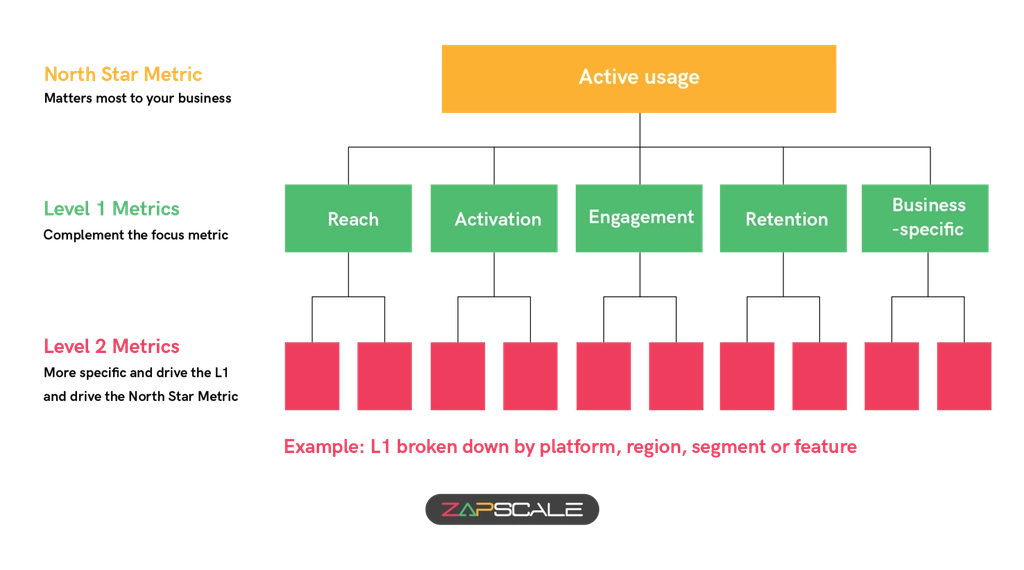

- KPI : Key Performance Indicator(핵심성과 지표)
    - 성공의 의미를 구체적으로 정의
    - 우선순위 파악
    - 끊임없이 방향 조정
    - 투명성
    - 패턴 분석

#### <span style="color: #000000;background-color: #ffc2e5">   **2-(4) AARRR(해적 지표)**</span>
- 넷플릭스, 유튜브, 스포티파이
    - 오래 감상할수록 광고 수익, 유저 리텐션 등에 좋은 영향을 끼침
    -> 컨텐츠 감상 시간이 중요한 지표
- 우버
    - 공급자와 수요자를 매칭하는 서비스
    - 택시를 부르는 사람들의 요청 중 몇 퍼센트가 실제로 매칭되는지 중요
=> <U>**프로덕트가 가치를 제공하는 방식이 다르면, 측정하는 지표도 달라져야 한다!**</U>
- AARRR 모델(해적지표) : 사용자 운영 과정에서 자주 활용되는 데이터 분석 모델로, 사용자 증가를 위한 5가지 로드맵 구성

##### <span style="color: #27baff">   **[1. Acquisition]** <span>
- 사용자가 여러 채널을 통해 앱 혹은 웹사이트에 방문하는 것
    - 채널 : 광고, 검색엔진 최적화, 지인 추천, 오프라인 행사 등 매우 다양
- 고민할 포인트 : '신규 고객을 어떻게 획득할지','어디로부터 획득할지','주로 어떤 채널을 통해 획득할지'
- 대체로 지표를 통해 측정
    - 예시
        - CAC (Customer Acquisition Cost): 유저 획득 비용
        - CTR (Cost Per Click): 클릭 한 건당 얼마 지출
        - CPC (Cost Per Install): 인스톨 당 과금되는 상품
        - CPL (Cost Per Lead): 유저 행동 당 드는 비용
        - ROAS (Return On Ads Spending): 광고로 인한 매출액/광고비

##### <span style="color: #27baff">   **[2. Activation]** <span>
- 사용자 활성화 : 앱 또는 웹사이트에 첫 방문하여 주요 기능을 직접 사용하는 것
- 제품의 성격에 따라 다양한 기준으로 측정
    - 예시
        - 초기 페이스북 : 회원가입 10일 내 최소 7명의 친구를 가진 신규 사용자를 측정 지표로 사용
        - 한 이커머스 앱 : 회원가입 3일 내 최소 1건을 주문한 신규 사용자를 측정 지표로 사용
- 4단계로 구성
    - Sign-up: 유저가 제품에 들어온 시점
    - Setup Moment: 유저가 제품의 핵심가치를 경험할 준비 완료
    - A-HA! Moment: 유저가 핵심가치를 처음 경험한 순간
    - Habit Moment: 유저가 제품 사용에 대한 습관 형성

##### <span style="color: #27baff">   **[3. Retention]** <span>
- 유지 단계 : 신규 사용자를 장기 사용자로 전환시키는 것에 초점(기존 사용자를 유지시키는 것이 신규 사용자 획득보다 저렴)
- 고민 포인트 : '어떻게 장기 고객을 양성할 것인지','어떻게 고객의 지속적인 구매 행위를 증가시킬 수 있을지'
- 측정 지표
    - DN Retention: N일 안으로 재접속하는 경우
    - MAU/DAU/WAU: 일/주/월마다 방문하는 횟수
    - Stickness(DAU, MAU): 해당기간 동안 활성화 수 (*점성)

##### <span style="color: #27baff">   **[4. Revenue]** <span>
- 수익 단계 : 사용자가 제품 혹은 서비스를 유료 구매하기로 결정한 단계
- 목적 : 사용자의 소비를 유도 -> 매출 증가
- 측정 지표 : 제품 성격에 따라 다양
- **고객의 평생 가치(STV)를 지속적으로 높여나가고, 고객 유치 비용은 계속해서 줄여나가야 한다**
- 지표 예시
    - PU(Paying User): 전체 사용자 중에 결제를 한 사용자 비율
    - Average Check: 구매 1회당 평균 금액 (Revenue/Transaction)
    - ARPU(Average Revenue Per User): 인당 평균 매출
    - ARPPU(Average Revenue Per Paying User): 결제자당 평균 매출
    - LTV(Life Time Value): 유저가 진입부터 이탈까지 누적 수익

##### <span style="color: #27baff">   **[5. Referral]** <span>
- 사용자가 타인에게 해당 상품 혹은 서비스를 추천
- 제품의 지속적인 성장을 위한 매우 중요한 단계
- 고민 포인트 : '어떻게 충성도 높은 사용자를 보이지 않는 브랜드 홍보자로 만들 것인가','어떻게 제품을 잠재 고객들에게 추천하도록 만들 것인가'
- 측정 지표 : 순 추천고객 지수(NPS), 바이럴 지수
- 지표 예시
    - 바이럴 계수: 기존 고객 한명당 데리고 온 새로운 고객의 수
        - 바이럴 계수가 1이 넘으면 Acquisition 단계를 하지 않아도 서비스가 성장
    - 바이럴 주기: 기존 고객 1명이 새로운 고객을 데려오는데 걸리는 시간

### <span style="color: #000000;background-color: #ffdba4">**3. 지표 분석 방법**</span>

#### <span style="color: #000000;background-color: #ffc2e5">   **3-(1) 코호트(Cohort) 분석**</span>
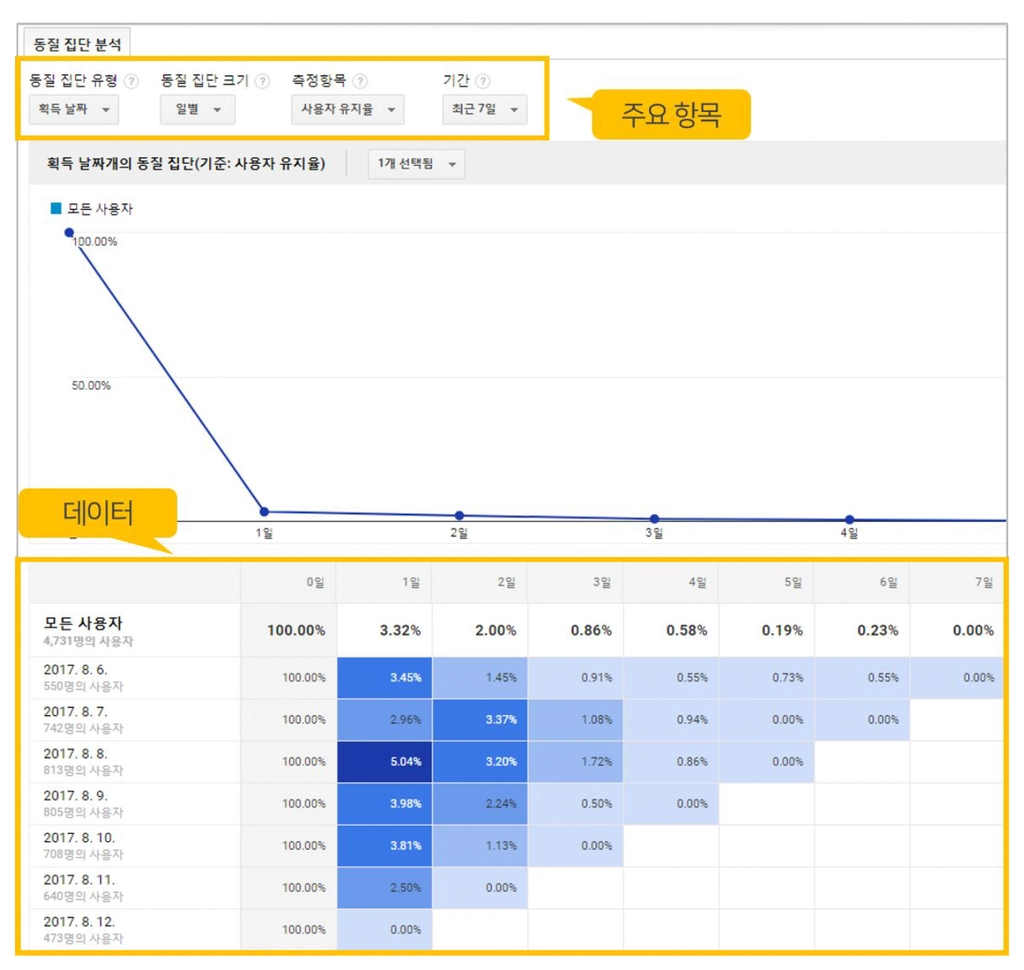

##### <span style="color: #27baff">   **[코호트 분석이란?]** <span>
- 코호트 : 동질 집단
    - 정의된 시간 범위 내에서 공통된 특성이나 경험을 공유하는 사용자 집단
    - <U>특정 기간에 특정 특성을 공유하는 사용자 집단</U>이 코호트, 이를 분석하는 것이 **코호트 분석**
- 분석 전에 데이터 세트의 데이터를 관련 그룹으로 나누는 일종의 행동 분석
- 시간에 기반하는 사용자 세그먼트를 분류한다고 이해
    - 세그먼트 : 전체 고객을 특정 기준으로 나눈 것
    - 코호트 : 동일한 기간에 동일한 특성을 가진 사람들을 분류
    -> 코호트는 '기간'이라는 개념을 포함한다!
- 주로 사용자 유지와 이탈을 체크하는 데 많이 사용

##### <span style="color: #27baff">   **[코호트 분석 해석 방법]** <span>
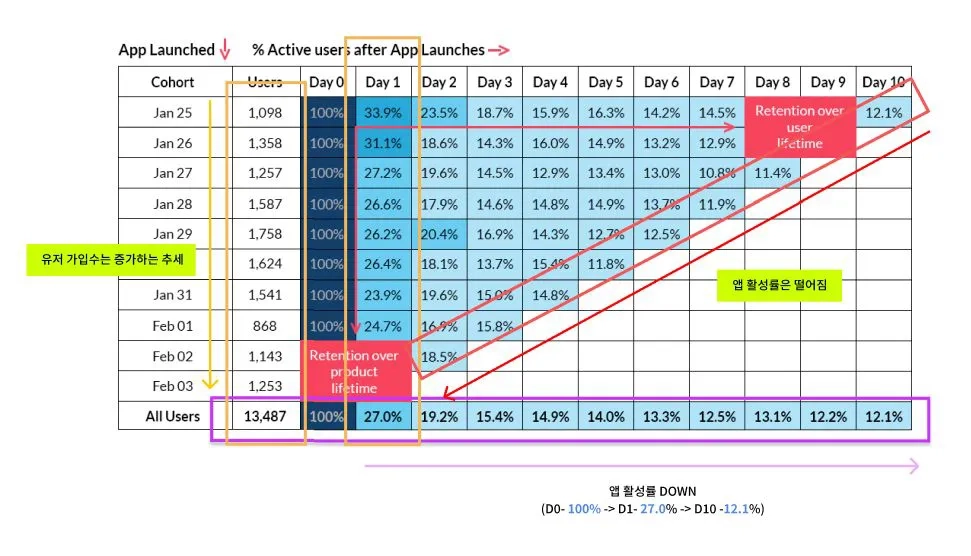

- **세로축(노란색) 방향: 코호트별 비교**
    - 같은 기간이 지난 후 코호트간 리텐션을 비교할 수 있다
        - ex) 신규 유저 가입자는 점점 증가하는 추세
- **대각선(빨간색) 방향: 시점별 비교**
    - ex) 2023년 3월부터 2024년 1월까지 보았을 때, 전반적인 고객들의 구매율이 점점 떨어지고 있음을 확인할 수 있다 (해당 그래프 X)       
- **가로축(보라색) 방향: 시간의 경과에 따른 변화 관찰**
    - ex) 첫 방문 이후 시간이 경과할수록 앱 활성률은 떨어진다.  
    
=> 가입자는 느는데 사람들이 잘 안쓴다 : Acquisition은 잘 작동하는데 Activation&Retention의 문제

#### <span style="color: #000000;background-color: #ffc2e5">   **3-(2) 퍼널(Funnel) 분석**</span>

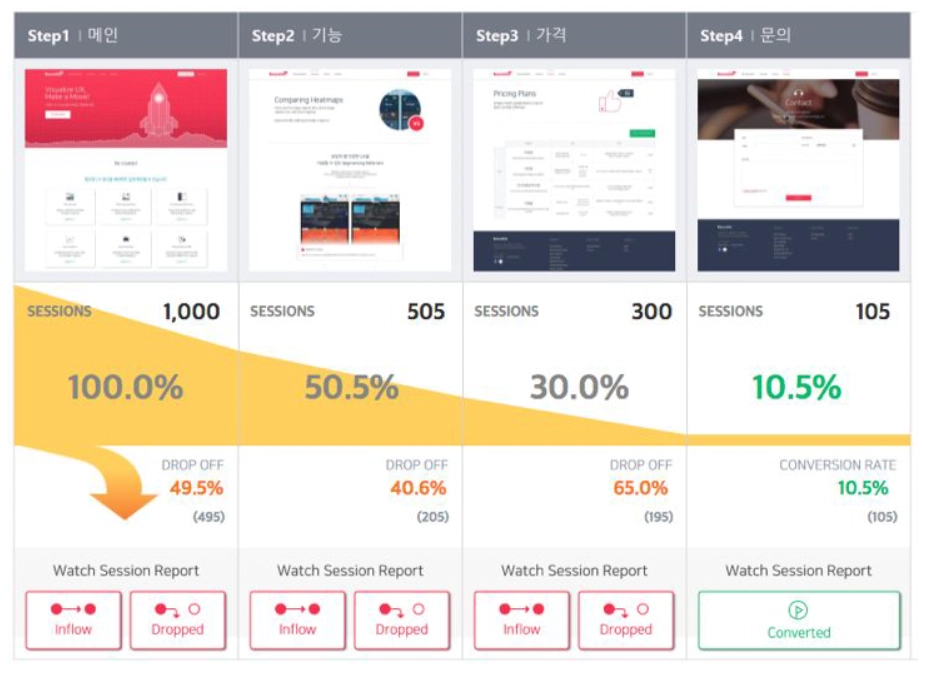
- 사용자가 접속해서 떠날 때까지 사용자의 행동 추적
- 소위 '깔때기'라고 불리며, 아래로 갈수록 점점 좁아짐(시간이 지날수록 사용자 이탈)

- 개선 방법 예시
    1. 유입률(Acquisition) 높이기
    2. 전환율(Activation) 높이기
    3. 퍼널 단계 없애기
    4. 퍼널 순서 바꾸기
    5. 퍼널 단계 추가하기
    6. 코호트로 나누어 보기